# 🩸 HémoVision — Analyse Exploratoire des Données (EDA)

> **Coding Week · Mars 2026** — Jay · Léandre Zadi · Adama Sana · Ilias Janati

Ce notebook explore le dataset **BMT Children** (Silesian University of Technology, Pologne).  
Il couvre : chargement, valeurs manquantes, distribution de la cible, variables continues, variables catégorielles, corrélations et conclusions.

---

**Table des matières**
1. [Chargement & aperçu](#1)
2. [Variable cible](#2)
3. [Valeurs manquantes](#3)
4. [Variables numériques](#4)
5. [Variables catégorielles clés](#5)
6. [Corrélations](#6)
7. [Data Leakage — colonnes exclues](#7)
8. [Conclusions](#8)

## ⚙️ Setup — Imports & Configuration

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.io import arff
import warnings
warnings.filterwarnings('ignore')

# Style global
NAVY   = '#0D2146'
CYAN   = '#0077B6'
TEAL   = '#00B4D8'
GREEN  = '#2E7D32'
RED    = '#C62828'
ORANGE = '#E65100'
GRAY   = '#B0BEC5'

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#F7F9FC',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.labelcolor':  NAVY,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
    'axes.titlecolor':  NAVY,
    'xtick.color':      '#4A6080',
    'ytick.color':      '#4A6080',
    'grid.color':       '#E0E8F0',
    'grid.linestyle':   '--',
    'grid.alpha':       0.7,
    'font.family':      'sans-serif',
})

PALETTE = {0.0: GREEN, 1.0: RED}
print('✅ Configuration chargée')

✅ Configuration chargée


## 1. Chargement & Aperçu <a id='1'></a>

In [19]:
# Chargement du fichier ARFF
data, meta = arff.loadarff('../data/bone-marrow.arff')
df = pd.DataFrame(data)

# Décodage bytes → str (encodage scipy)
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].str.decode('utf-8')

# Remplacement des '?' ARFF par NaN
# Sans cette étape, '?' serait traité comme une vraie catégorie
# et créerait de fausses colonnes après OHE (ex: CMVstatus_?)
df.replace('?', np.nan, inplace=True)

print(f'Shape : {df.shape[0]} patients × {df.shape[1]} variables')
print(f'Mémoire : {df.memory_usage(deep=True).sum() / 1024:.1f} KB')
df.head()

Shape : 187 patients × 37 variables
Mémoire : 253.5 KB


,Recipientgender,Stemcellsource,Donorage,Donorage35,IIIV,Gendermatch,DonorABO,RecipientABO,RecipientRh,ABOmatch,...,extcGvHD,CD34kgx10d6,CD3dCD34,CD3dkgx10d8,Rbodymass,ANCrecovery,PLTrecovery,time_to_aGvHD_III_IV,survival_time,survival_status
0,1,1,22.830137,0,1,0,1,1,1,0,...,1,7.20,1.338760,5.38,35.0,19.0,51.0,32.0,999.0,0.0
1,1,0,23.342466,0,1,0,-1,-1,1,0,...,1,4.50,11.078295,0.41,20.6,16.0,37.0,1000000.0,163.0,1.0
2,1,0,26.394521,0,1,0,-1,-1,1,0,...,1,7.94,19.013230,0.42,23.4,23.0,20.0,1000000.0,435.0,1.0
3,0,0,39.684932,1,1,0,1,2,1,1,...,NaN,4.25,29.481647,0.14,50.0,23.0,29.0,19.0,53.0,1.0
4,0,1,33.358904,0,0,0,1,2,0,1,...,1,51.85,3.972255,13.05,9.0,14.0,14.0,1000000.0,2043.0,0.0


In [20]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
display(df)

,Recipientgender,Stemcellsource,Donorage,Donorage35,IIIV,Gendermatch,DonorABO,RecipientABO,RecipientRh,ABOmatch,CMVstatus,DonorCMV,RecipientCMV,Disease,Riskgroup,Txpostrelapse,Diseasegroup,HLAmatch,HLAmismatch,Antigen,Alel,HLAgrI,Recipientage,Recipientage10,Recipientageint,Relapse,aGvHDIIIIV,extcGvHD,CD34kgx10d6,CD3dCD34,CD3dkgx10d8,Rbodymass,ANCrecovery,PLTrecovery,time_to_aGvHD_III_IV,survival_time,survival_status
0,1,1,22.830137,0,1,0,1,1,1,0,3,1,1,ALL,1,0,1,0,0,-1,-1,0,9.6,0,1,0,0,1,7.200,1.338760,5.38,35.00,19.0,51.0,32.0,999.0,0.0
1,1,0,23.342466,0,1,0,-1,-1,1,0,0,0,0,ALL,0,0,1,0,0,-1,-1,0,4.0,0,0,1,1,1,4.500,11.078295,0.41,20.60,16.0,37.0,1000000.0,163.0,1.0
2,1,0,26.394521,0,1,0,-1,-1,1,0,2,0,1,ALL,0,0,1,0,0,-1,-1,0,6.6,0,1,1,1,1,7.940,19.013230,0.42,23.40,23.0,20.0,1000000.0,435.0,1.0
3,0,0,39.684932,1,1,0,1,2,1,1,1,1,0,AML,0,0,1,0,0,-1,-1,0,18.1,1,2,0,0,NaN,4.250,29.481647,0.14,50.00,23.0,29.0,19.0,53.0,1.0
4,0,1,33.358904,0,0,0,1,2,0,1,0,0,1,chronic,1,0,1,1,0,1,0,1,1.3,0,0,0,1,1,51.850,3.972255,13.05,9.00,14.0,14.0,1000000.0,2043.0,0.0
5,1,0,27.391781,0,0,0,2,0,1,1,NaN,NaN,1,chronic,1,1,1,0,0,-1,-1,0,8.9,0,1,0,1,1,3.270,8.412758,0.39,40.00,16.0,70.0,1000000.0,2800.0,0.0
6,0,1,34.520548,0,1,0,0,1,0,1,NaN,0,NaN,AML,0,0,1,0,0,-1,-1,0,14.4,1,2,0,0,NaN,17.780,2.406248,7.39,51.00,17.0,29.0,18.0,41.0,1.0
7,1,0,21.435616,0,1,0,0,1,1,1,1,1,0,nonmalignant,0,0,0,3,1,1,2,7,18.2,1,2,0,0,NaN,6.410,NaN,NaN,56.00,22.0,58.0,22.0,45.0,1.0
8,1,1,32.641096,0,0,0,2,0,1,1,2,0,1,nonmalignant,0,0,0,0,0,-1,-1,0,7.9,0,1,0,1,1,23.540,3.772555,6.24,20.50,15.0,14.0,1000000.0,671.0,0.0
9,1,1,28.783562,0,1,1,1,0,1,1,2,0,1,nonmalignant,0,0,0,1,0,0,1,3,4.7,0,0,0,1,1,7.690,1.035244,7.43,16.50,16.0,17.0,1000000.0,676.0,0.0


In [21]:
# Types de colonnes
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print(f'Variables numériques ({len(num_cols)}) :', num_cols)
print()
print(f'Variables catégorielles ({len(cat_cols)}) :', cat_cols)

Variables numériques (11) : ['Donorage', 'Recipientage', 'CD34kgx10d6', 'CD3dCD34', 'CD3dkgx10d8', 'Rbodymass', 'ANCrecovery', 'PLTrecovery', 'time_to_aGvHD_III_IV', 'survival_time', 'survival_status']

Variables catégorielles (26) : ['Recipientgender', 'Stemcellsource', 'Donorage35', 'IIIV', 'Gendermatch', 'DonorABO', 'RecipientABO', 'RecipientRh', 'ABOmatch', 'CMVstatus', 'DonorCMV', 'RecipientCMV', 'Disease', 'Riskgroup', 'Txpostrelapse', 'Diseasegroup', 'HLAmatch', 'HLAmismatch', 'Antigen', 'Alel', 'HLAgrI', 'Recipientage10', 'Recipientageint', 'Relapse', 'aGvHDIIIIV', 'extcGvHD']


## 2. Variable Cible — `survival_status` <a id='2'></a>

`0` = Survie · `1` = Décès

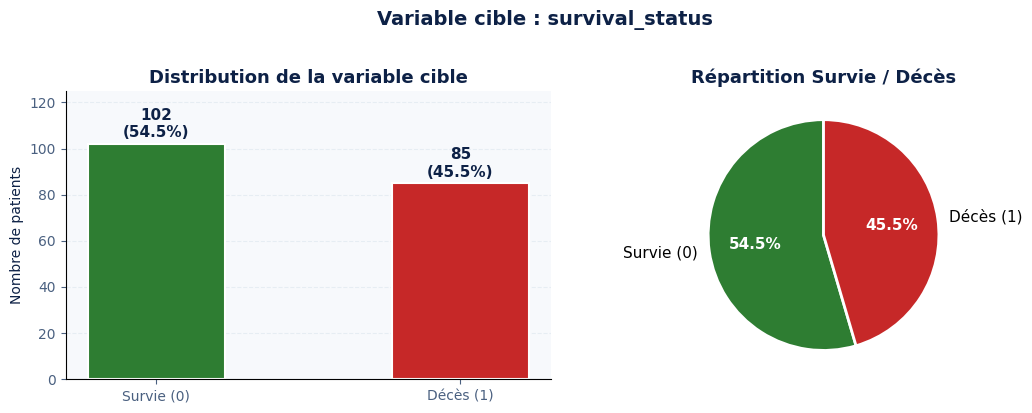

Ratio Survie/Décès : 1.20
→ Déséquilibre modéré → traitement par SMOTE sur le train set uniquement


In [22]:
target_counts = df['survival_status'].value_counts().sort_index()
labels = ['Survie (0)', 'Décès (1)']
colors = [GREEN, RED]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Barplot
bars = axes[0].bar(labels, target_counts.values, color=colors, width=0.45, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, target_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
                 f'{val}\n({val/len(df)*100:.1f}%)', ha='center', va='bottom',
                 fontsize=11, fontweight='bold', color=NAVY)
axes[0].set_title('Distribution de la variable cible')
axes[0].set_ylabel('Nombre de patients')
axes[0].set_ylim(0, 125)
axes[0].yaxis.grid(True); axes[0].set_axisbelow(True)

# Pie
wedges, texts, autotexts = axes[1].pie(
    target_counts.values, labels=labels, colors=colors,
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 11}
)
for at in autotexts:
    at.set_fontweight('bold'); at.set_color('white')
axes[1].set_title('Répartition Survie / Décès')

plt.suptitle('Variable cible : survival_status', fontsize=14, fontweight='bold', color=NAVY, y=1.02)
plt.tight_layout()
plt.show()

print(f'Ratio Survie/Décès : {target_counts[0.0]/target_counts[1.0]:.2f}')
print('→ Déséquilibre modéré → traitement par SMOTE sur le train set uniquement')

## 3. Valeurs Manquantes <a id='3'></a>

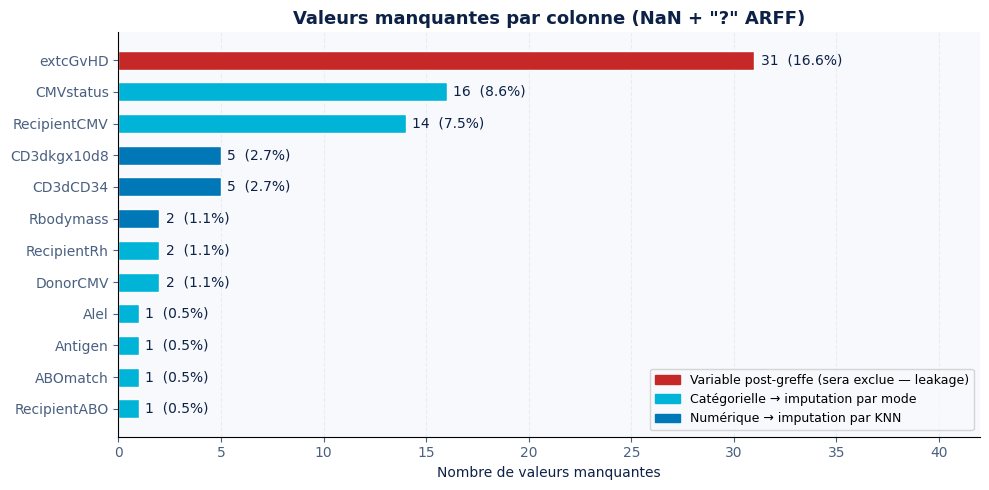

Total valeurs manquantes : 81 / 6919 (1.17%)
⚠️  extcGvHD : 31 valeurs manquantes (16.6%) — variable POST-greffe, exclue du modèle


In [23]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=True)
pct     = (missing / len(df) * 100).round(1)

# Type de chaque colonne manquante
col_types = ['Post-greffe ⚠️' if c in
             ['extcGvHD','IIIV','Relapse','aGvHDIIIIV','ANCrecovery','PLTrecovery','time_to_aGvHD_III_IV']
             else 'Catégorielle' if c in cat_cols else 'Numérique'
             for c in missing.index]

bar_colors = [RED if 'Post' in t else TEAL if 'Cat' in t else CYAN for t in col_types]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(missing.index, missing.values, color=bar_colors, edgecolor='white', height=0.6)
for bar, val, p in zip(bars, missing.values, pct):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val}  ({p}%)', va='center', fontsize=10, color=NAVY)
ax.set_xlim(0, 42)
ax.set_xlabel('Nombre de valeurs manquantes')
ax.set_title('Valeurs manquantes par colonne (NaN + "?" ARFF)')
ax.xaxis.grid(True); ax.set_axisbelow(True)

legend_patches = [
    mpatches.Patch(color=RED,  label='Variable post-greffe (sera exclue — leakage)'),
    mpatches.Patch(color=TEAL, label='Catégorielle → imputation par mode'),
    mpatches.Patch(color=CYAN, label='Numérique → imputation par KNN'),
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

print(f'Total valeurs manquantes : {missing.sum()} / {df.size} ({missing.sum()/df.size*100:.2f}%)')
print('⚠️  extcGvHD : 31 valeurs manquantes (16.6%) — variable POST-greffe, exclue du modèle')

## 4. Variables Numériques <a id='4'></a>

In [24]:
# Statistiques descriptives des variables pré-greffe uniquement
preop_num = ['Donorage', 'Recipientage', 'CD34kgx10d6', 'CD3dCD34', 'CD3dkgx10d8', 'Rbodymass']
df[preop_num].describe().round(2)

,Donorage,Recipientage,CD34kgx10d6,CD3dCD34,CD3dkgx10d8,Rbodymass
count,187.00,187.00,187.00,182.00,182.00,185.00
mean,33.47,9.93,11.89,5.39,4.75,35.80
std,8.27,5.31,9.91,9.60,3.86,19.65
min,18.65,0.60,0.79,0.20,0.04,6.00
25%,27.04,5.05,5.35,1.79,1.69,19.00
50%,33.55,9.60,9.72,2.73,4.32,33.00
75%,40.12,14.05,15.42,5.82,6.78,50.60
max,55.55,20.20,57.78,99.56,20.02,103.40


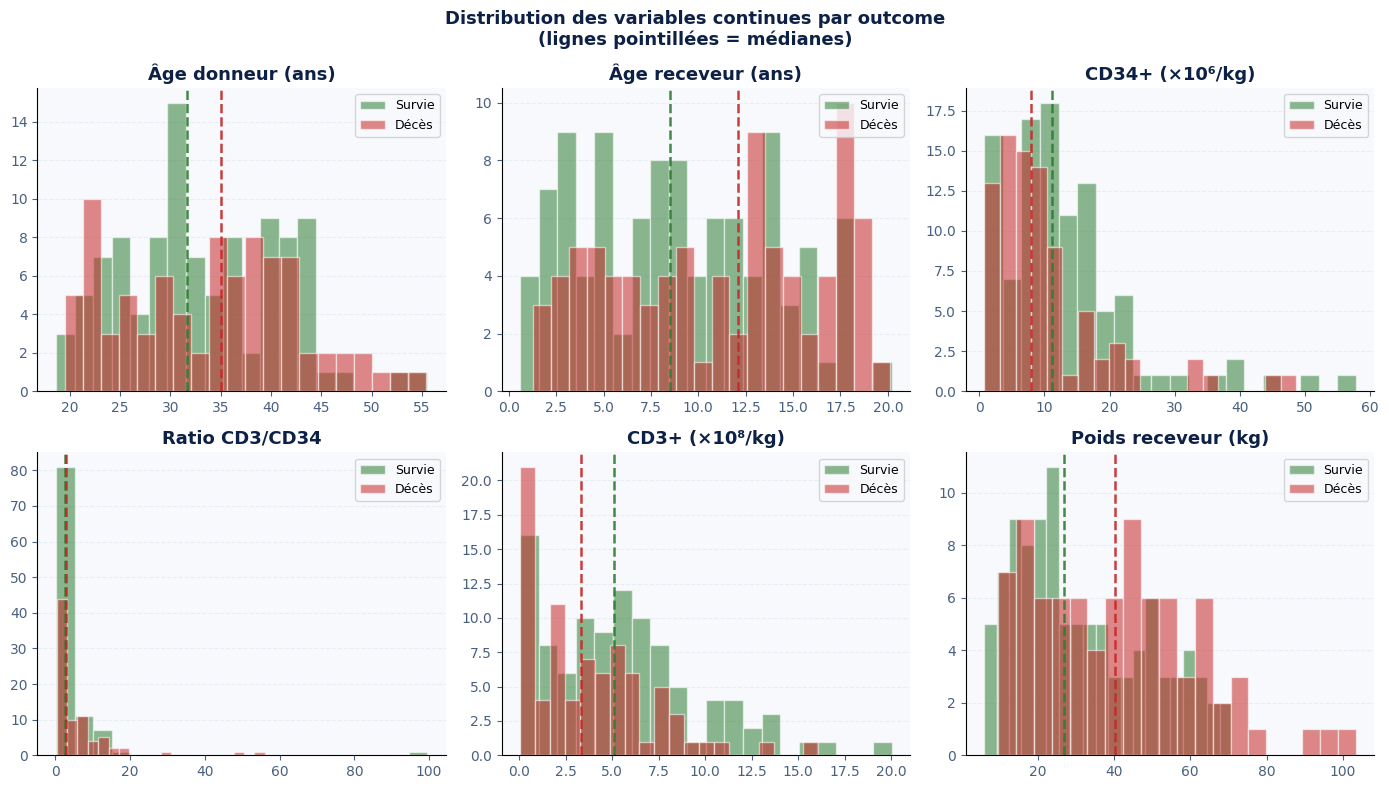

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

labels_map = {
    'Donorage':     'Âge donneur (ans)',
    'Recipientage': 'Âge receveur (ans)',
    'CD34kgx10d6':  'CD34+ (×10⁶/kg)',
    'CD3dCD34':     'Ratio CD3/CD34',
    'CD3dkgx10d8':  'CD3+ (×10⁸/kg)',
    'Rbodymass':    'Poids receveur (kg)',
}

for ax, col in zip(axes, preop_num):
    for val, color, lbl in [(0.0, GREEN, 'Survie'), (1.0, RED, 'Décès')]:
        subset = df[df['survival_status'] == val][col].dropna()
        ax.hist(subset, bins=20, alpha=0.55, color=color, label=lbl, edgecolor='white')
        ax.axvline(subset.median(), color=color, linewidth=1.8, linestyle='--', alpha=0.9)
    ax.set_title(labels_map[col])
    ax.set_xlabel('')
    ax.yaxis.grid(True); ax.set_axisbelow(True)
    ax.legend(fontsize=9)

plt.suptitle('Distribution des variables continues par outcome\n(lignes pointillées = médianes)',
             fontsize=13, fontweight='bold', color=NAVY)
plt.tight_layout()
plt.show()

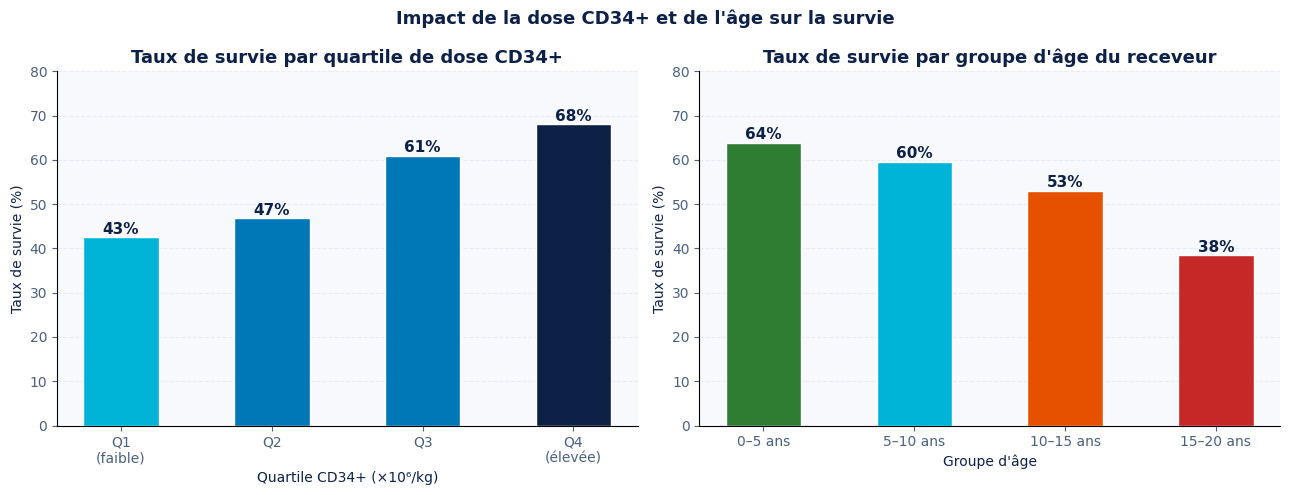

→ Q4 CD34+ : taux de survie de 68% vs Q1 : 43% — corrélation négative avec le décès (-0.147)
→ 15-20 ans : taux de survie de 38% vs 0-5 ans : 64% — corrélation positive avec le décès (+0.203)


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# CD34 par quartile
df['cd34_q'] = pd.qcut(df['CD34kgx10d6'], q=4, labels=['Q1\n(faible)','Q2','Q3','Q4\n(élevée)'])
cd34_grp = df.groupby('cd34_q', observed=True)['survival_status'].mean() * 100
bars = axes[0].bar(cd34_grp.index, 100 - cd34_grp.values,
                   color=[TEAL, CYAN, '#0077B6', NAVY], edgecolor='white', width=0.5)
for bar, val in zip(bars, 100 - cd34_grp.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
                 f'{val:.0f}%', ha='center', fontsize=11, fontweight='bold', color=NAVY)
axes[0].set_ylim(0, 80)
axes[0].set_title('Taux de survie par quartile de dose CD34+')
axes[0].set_xlabel('Quartile CD34+ (×10⁶/kg)')
axes[0].set_ylabel('Taux de survie (%)')
axes[0].yaxis.grid(True); axes[0].set_axisbelow(True)

# Âge receveur par groupe
df['age_group'] = pd.cut(df['Recipientage'], bins=[0,5,10,15,20.5],
                          labels=['0–5 ans','5–10 ans','10–15 ans','15–20 ans'])
age_grp = df.groupby('age_group', observed=True)['survival_status'].mean() * 100
bar_colors = [GREEN, TEAL, ORANGE, RED]
bars2 = axes[1].bar(age_grp.index, 100 - age_grp.values,
                    color=bar_colors, edgecolor='white', width=0.5)
for bar, val in zip(bars2, 100 - age_grp.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
                 f'{val:.0f}%', ha='center', fontsize=11, fontweight='bold', color=NAVY)
axes[1].set_ylim(0, 80)
axes[1].set_title('Taux de survie par groupe d\'âge du receveur')
axes[1].set_xlabel('Groupe d\'âge')
axes[1].set_ylabel('Taux de survie (%)')
axes[1].yaxis.grid(True); axes[1].set_axisbelow(True)

plt.suptitle('Impact de la dose CD34+ et de l\'âge sur la survie',
             fontsize=13, fontweight='bold', color=NAVY)
plt.tight_layout()
plt.show()

print('→ Q4 CD34+ : taux de survie de 68% vs Q1 : 43% — corrélation négative avec le décès (-0.147)')
print('→ 15-20 ans : taux de survie de 38% vs 0-5 ans : 64% — corrélation positive avec le décès (+0.203)')

## 5. Variables Catégorielles Clés <a id='5'></a>

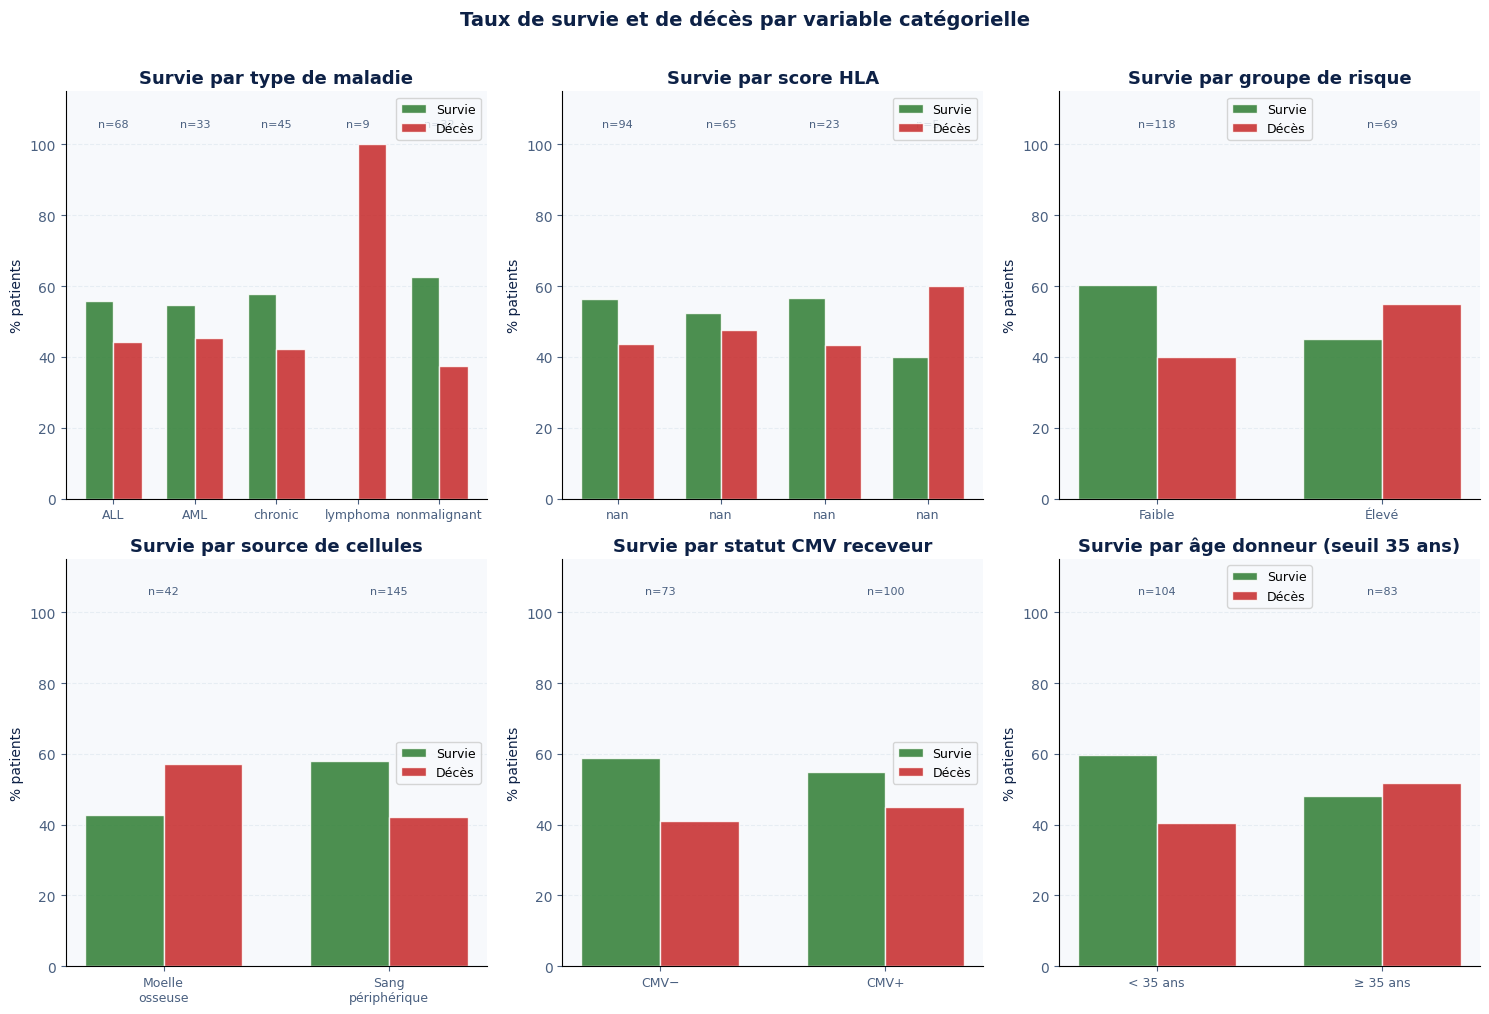

In [27]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

def survival_barplot(ax, col, title, label_map=None):
    grp = df.groupby(col, dropna=True)['survival_status'].agg(['mean','count'])
    grp['survive_pct'] = (1 - grp['mean']) * 100
    grp['die_pct']     = grp['mean'] * 100
    idx = grp.index.map(label_map) if label_map else grp.index
    x   = np.arange(len(grp))
    w   = 0.35
    ax.bar(x - w/2, grp['survive_pct'].values, w, label='Survie', color=GREEN, alpha=0.85, edgecolor='white')
    ax.bar(x + w/2, grp['die_pct'].values,     w, label='Décès',  color=RED,   alpha=0.85, edgecolor='white')
    ax.set_xticks(x); ax.set_xticklabels(idx, fontsize=9)
    ax.set_ylim(0, 115)
    ax.set_ylabel('% patients'); ax.set_title(title)
    ax.yaxis.grid(True); ax.set_axisbelow(True)
    # Effectifs
    for i, n in enumerate(grp['count'].values):
        ax.text(i, 105, f'n={n}', ha='center', fontsize=8, color='#4A6080')
    ax.legend(fontsize=9)

survival_barplot(axes[0,0], 'Disease', 'Survie par type de maladie')

survival_barplot(axes[0,1], 'HLAmatch', 'Survie par score HLA',
                 {0:'10/10\n(parfait)', 1:'9/10', 2:'8/10', 3:'7/10'})

survival_barplot(axes[0,2], 'Riskgroup', 'Survie par groupe de risque',
                 {'0':'Faible', '1':'Élevé'})

survival_barplot(axes[1,0], 'Stemcellsource', 'Survie par source de cellules',
                 {'0':'Moelle\nosseuse', '1':'Sang\npériphérique'})

survival_barplot(axes[1,1], 'RecipientCMV', 'Survie par statut CMV receveur',
                 {'0':'CMV−', '1':'CMV+'})

# Donneur âge < 35
df['donor_group'] = df['Donorage'].apply(lambda x: '≥ 35 ans' if x >= 35 else '< 35 ans')
survival_barplot(axes[1,2], 'donor_group', 'Survie par âge donneur (seuil 35 ans)')

plt.suptitle('Taux de survie et de décès par variable catégorielle',
             fontsize=14, fontweight='bold', color=NAVY, y=1.01)
plt.tight_layout()
plt.show()

In [28]:
# Tableau récapitulatif Maladie × Survie
summary = df.groupby('Disease')['survival_status'].agg(
    Effectif='count',
    Décès='sum',
    Survie=lambda x: (x == 0).sum(),
    Taux_survie=lambda x: f"{(x == 0).mean()*100:.0f}%"
).reset_index()
summary.columns = ['Maladie', 'Effectif', 'Décès', 'Survie', 'Taux de survie']
print('Survie par type de maladie :')
print(summary.to_string(index=False))
print()
print('⚠️  Lymphome : 0% de survie (n=9) — signal très fort mais échantillon non représentatif')
print('✅  Non-malignes : meilleur pronostic (62% de survie)')

Survie par type de maladie :
     Maladie  Effectif  Décès  Survie Taux de survie
         ALL        68   30.0      38            56%
         AML        33   15.0      18            55%
     chronic        45   19.0      26            58%
    lymphoma         9    9.0       0             0%
nonmalignant        32   12.0      20            62%

⚠️  Lymphome : 0% de survie (n=9) — signal très fort mais échantillon non représentatif
✅  Non-malignes : meilleur pronostic (62% de survie)


## 6. Corrélations <a id='6'></a>

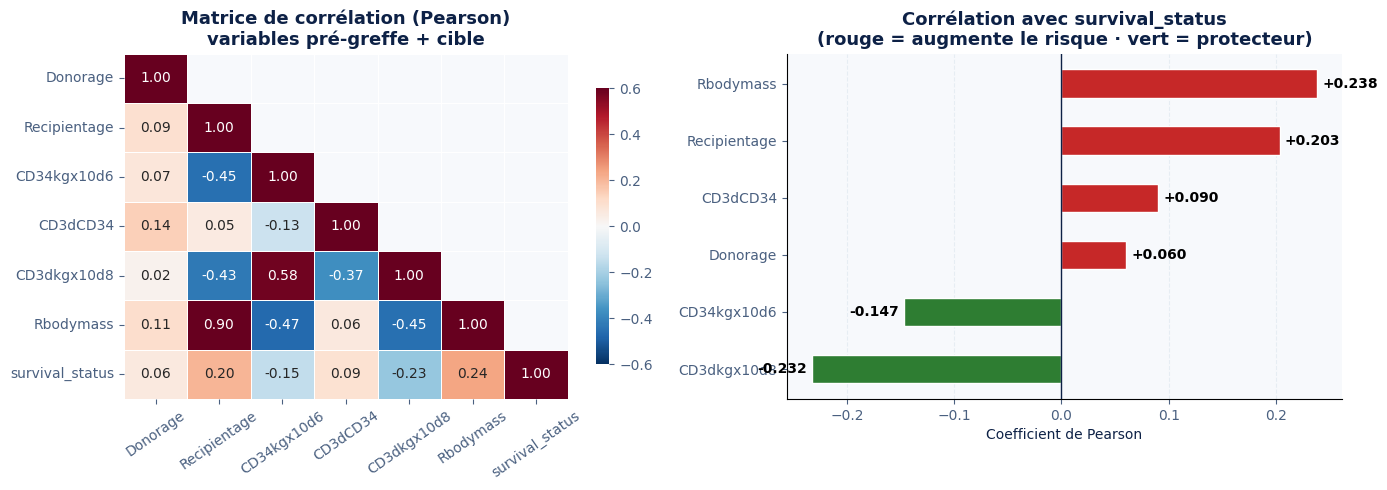

Variables les plus corrélées avec le décès (positif → risque) :
  CD3dkgx10d8       : -0.232  ↓ risque
  CD34kgx10d6       : -0.147  ↓ risque
  Donorage          : +0.060  ↑ risque
  CD3dCD34          : +0.090  ↑ risque
  Recipientage      : +0.203  ↑ risque
  Rbodymass         : +0.238  ↑ risque


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Heatmap corrélation ---
corr_matrix = df[preop_num + ['survival_status']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, vmin=-0.6, vmax=0.6,
    mask=mask, ax=axes[0],
    linewidths=0.5, linecolor='white',
    cbar_kws={'shrink': 0.8}
)
axes[0].set_title('Matrice de corrélation (Pearson)\nvariables pré-greffe + cible')
axes[0].tick_params(axis='x', rotation=35)

# --- Corrélations avec la cible ---
corr_target = corr_matrix['survival_status'].drop('survival_status').sort_values()
bar_cols = [RED if v > 0 else GREEN for v in corr_target.values]
bars = axes[1].barh(corr_target.index, corr_target.values,
                    color=bar_cols, edgecolor='white', height=0.5)
axes[1].axvline(0, color=NAVY, linewidth=1)
for bar, val in zip(bars, corr_target.values):
    axes[1].text(val + (0.005 if val >= 0 else -0.005),
                 bar.get_y() + bar.get_height()/2,
                 f'{val:+.3f}', va='center',
                 ha='left' if val >= 0 else 'right',
                 fontsize=10, fontweight='bold')
axes[1].set_title('Corrélation avec survival_status\n(rouge = augmente le risque · vert = protecteur)')
axes[1].set_xlabel('Coefficient de Pearson')
axes[1].xaxis.grid(True); axes[1].set_axisbelow(True)

plt.tight_layout()
plt.show()

print('Variables les plus corrélées avec le décès (positif → risque) :')
for col, val in corr_target.items():
    direction = '↑ risque' if val > 0 else '↓ risque'
    print(f'  {col:18s}: {val:+.3f}  {direction}')

## 7. Data Leakage — Colonnes Exclues <a id='7'></a>

Certaines variables ne sont **pas disponibles au moment de la décision clinique** (avant la greffe).  
Les inclure dans le modèle gonflerait artificiellement les métriques sans valeur prédictive réelle.

In [30]:
LEAKAGE_COLS = {
    'IIIV':                  'GvHD aiguë stade II/III/IV — observable après greffe',
    'Relapse':               'Rechute de la maladie — survient après greffe',
    'aGvHDIIIIV':            'GvHD aiguë stade III/IV — post-greffe',
    'extcGvHD':              'GvHD chronique extensive — post-greffe',
    'ANCrecovery':           'Temps récupération neutrophiles — post-greffe',
    'PLTrecovery':           'Temps récupération plaquettes — post-greffe',
    'time_to_aGvHD_III_IV':  'Délai avant GvHD III/IV — post-greffe',
    'survival_time':         'Durée de survie — leakage évident',
}

REDUNDANT_COLS = {
    'Donorage35':     'Binarisation de Donorage (seuil 35 ans)',
    'Recipientage10': 'Binarisation de Recipientage (seuil 10 ans)',
    'Recipientageint':'Recipientage découpé en intervalles',
    'HLAmismatch':    'Binarisation de HLAmatch',
    'Diseasegroup':   'Binarisation de Disease (maligne/non-maligne)',
}

print('🚫 Colonnes POST-GREFFE exclues (data leakage) :')
for col, reason in LEAKAGE_COLS.items():
    print(f'   {col:28s} → {reason}')

print()
print('🔁 Colonnes REDONDANTES exclues (multicolinéarité) :')
for col, reason in REDUNDANT_COLS.items():
    print(f'   {col:28s} → {reason}')

print()
all_excl = list(LEAKAGE_COLS.keys()) + list(REDUNDANT_COLS.keys()) + ['survival_status']
features_kept = [c for c in df.columns if c not in all_excl]
print(f'✅ Variables conservées pour le ML : {len(features_kept)} / {len(df.columns)}')
print('   ', features_kept)

🚫 Colonnes POST-GREFFE exclues (data leakage) :
   IIIV                         → GvHD aiguë stade II/III/IV — observable après greffe
   Relapse                      → Rechute de la maladie — survient après greffe
   aGvHDIIIIV                   → GvHD aiguë stade III/IV — post-greffe
   extcGvHD                     → GvHD chronique extensive — post-greffe
   ANCrecovery                  → Temps récupération neutrophiles — post-greffe
   PLTrecovery                  → Temps récupération plaquettes — post-greffe
   time_to_aGvHD_III_IV         → Délai avant GvHD III/IV — post-greffe
   survival_time                → Durée de survie — leakage évident

🔁 Colonnes REDONDANTES exclues (multicolinéarité) :
   Donorage35                   → Binarisation de Donorage (seuil 35 ans)
   Recipientage10               → Binarisation de Recipientage (seuil 10 ans)
   Recipientageint              → Recipientage découpé en intervalles
   HLAmismatch                  → Binarisation de HLAmatch
   Disea

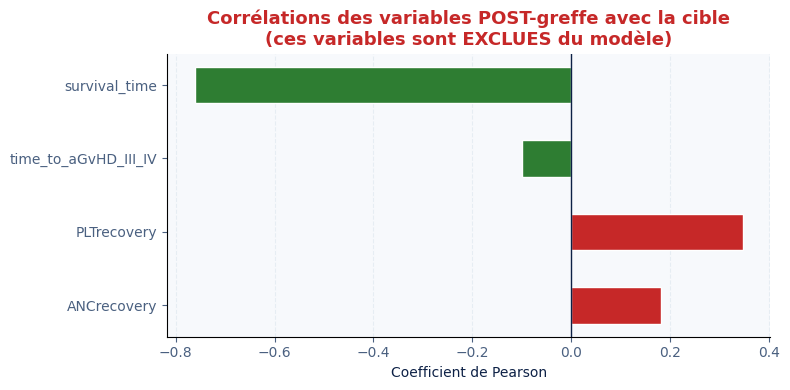

→ Ces fortes corrélations confirment pourquoi les garder serait du leakage.


In [31]:
# Visualisation : corrélation des variables post-greffe avec la cible
# (pour illustrer pourquoi elles SERAIENT très prédictives si on les gardait)
post_cols = [c for c in LEAKAGE_COLS.keys() if c in df.select_dtypes(include=[np.number]).columns]
post_cols_exist = [c for c in post_cols if c in df.columns]

if post_cols_exist:
    corr_post = df[post_cols_exist + ['survival_status']].corr()['survival_status'].drop('survival_status')
    fig, ax = plt.subplots(figsize=(8, 4))
    bar_cols = [RED if v > 0 else GREEN for v in corr_post.values]
    ax.barh(corr_post.index, corr_post.values, color=bar_cols, edgecolor='white', height=0.5)
    ax.axvline(0, color=NAVY, linewidth=1)
    ax.set_title('Corrélations des variables POST-greffe avec la cible\n(ces variables sont EXCLUES du modèle)',
                 color=RED)
    ax.set_xlabel('Coefficient de Pearson')
    ax.xaxis.grid(True); ax.set_axisbelow(True)
    plt.tight_layout()
    plt.show()
    print('→ Ces fortes corrélations confirment pourquoi les garder serait du leakage.')

## 8. Conclusions <a id='8'></a>

In [32]:
print('=' * 65)
print('  RÉSUMÉ EDA — HémoVision (BMT Children Dataset)')
print('=' * 65)
print()
print('📦 Dataset')
print('   187 patients × 37 variables')
print('   24 variables conservées → 44 features après OHE')
print()
print('🎯 Variable cible')
print('   Survie : 102 (54.5%)  |  Décès : 85 (45.5%)')
print('   Déséquilibre modéré → SMOTE sur le train set')
print()
print('🔍 Valeurs manquantes')
print('   81 valeurs manquantes au total (1.2%)')
print('   Dont 69 encodées "?" (convention ARFF) non détectées sans traitement')
print('   → KNN pour les numériques, Mode pour les catégorielles')
print()
print('📊 Variables les plus discriminantes (EDA)')
print('   • CD34kgx10d6 : dose élevée → meilleure survie (Q4 : 68% vs Q1 : 43%)')
print('   • Recipientage : âge élevé → risque accru (15-20 ans : 38% survie)')
print('   • Riskgroup : haut risque → 45% survie vs 60% pour risque faible')
print('   • Disease : lymphome → 0% survie (n=9), non-malignes → 62%')
print('   • Donorage < 35 ans → meilleur pronostic (60% vs 48%)')
print('   • Stemcellsource : sang périphérique → meilleur pronostic (58% vs 43%)')
print()
print('🚫 Data Leakage')
print('   8 colonnes post-greffe exclues + 5 redondantes')
print('   → Modèle honnête, prédictions exploitables en pratique clinique')
print()
print('✅ Prochaine étape : train_model.py → XGBoost + RF + SVM')

  RÉSUMÉ EDA — HémoVision (BMT Children Dataset)

📦 Dataset
   187 patients × 37 variables
   24 variables conservées → 44 features après OHE

🎯 Variable cible
   Survie : 102 (54.5%)  |  Décès : 85 (45.5%)
   Déséquilibre modéré → SMOTE sur le train set

🔍 Valeurs manquantes
   81 valeurs manquantes au total (1.2%)
   Dont 69 encodées "?" (convention ARFF) non détectées sans traitement
   → KNN pour les numériques, Mode pour les catégorielles

📊 Variables les plus discriminantes (EDA)
   • CD34kgx10d6 : dose élevée → meilleure survie (Q4 : 68% vs Q1 : 43%)
   • Recipientage : âge élevé → risque accru (15-20 ans : 38% survie)
   • Riskgroup : haut risque → 45% survie vs 60% pour risque faible
   • Disease : lymphome → 0% survie (n=9), non-malignes → 62%
   • Donorage < 35 ans → meilleur pronostic (60% vs 48%)
   • Stemcellsource : sang périphérique → meilleur pronostic (58% vs 43%)

🚫 Data Leakage
   8 colonnes post-greffe exclues + 5 redondantes
   → Modèle honnête, prédictions exploi